<a href="https://colab.research.google.com/github/Tedodor423/bms-collab-notebooks/blob/main/stats/1.3_DataWrangling/1.3_Assignment_DavidTheodorNimrichtr.ipynb" target="_parent">OPEN IN GOOGLE COLAB</a>

# Crime Survey Dataset Analysis
#### by David Theodor Nimrichtr

### How was the dateset colected?
This dataset was extracted from the Crime Survey England and Wales 2013. It contains 9300 responses.
*The Crime Survey for England and Wales (CSEW) is a face-to-face victimisation survey in which
people resident in households in England and Wales are asked about their experiences of a range of
crimes in the 12 months prior to the interview. Respondents to the survey are also asked about their
perceptions of crime and attitudes towards crime related issues such as the police and criminal justice
system.*

### Analysis goals
1. **Which groups are the most likely to be victims of crime?**
2. **What factors affect confidence in policing?**

**Note:** *The survey was conducted in 2013 in the UK. Events of recent years may have affected the confidence of certain groups in the police; this would not be reflected in the data used here.*


In [18]:
# Set-up Python libraries
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
sns.set_theme(style='white')

# Load dataset
crime  = pd.read_csv('https://raw.githubusercontent.com/Tedodor423/bms-collab-notebooks/refs/heads/main/stats/data/CrimeData_2013.csv')

# define functions
def print_counts_percentages(series_to_print, series_index = None):
    if series_index is None: series_index = series_to_print.index

    for i in range(len(series_to_print)):
        print(series_index[i],
            "\n- count:", series_to_print[i],
            "\n- percentage:", round(series_to_print[i]/len(crime)*100,2), "%")

## 0. Errors in the dataset
A lot of blank values had to be corrected for instances where respondents did not answer the question. Notably over 8 % of respondents did not fill out their income.

The dataset also shows a lot of **bias** towards certain demographics, especially the white ethnic background (91 %) and high socioeconomic status (managerial/proffessional occupancies, 38 %). The ethnicity can probably be attributed to the demographic composition of English/Welsh population, but still some bias could effect the results.

The dataset is otherwise well distributed across age, income, and education.

In [ ]:
# Before Cleanup
crime.describe()
plt.figure(figsize=(15,10))
plt.suptitle("Before cleanup", fontsize=16)
for i, col in enumerate(crime.columns):
    plt.subplot(3, 4, i+1)
    sns.histplot(crime[col])
plt.tight_layout()

# Cleanup
# - Sex seems OK
# - Age has a few more 99s than expected, and as other columns use 99 for bad values I will also consider it as such
# - AgeGroup seems OK
# - EthnicGroup seems OK, although the groups are unevenly represented
# - Edution should definitely not have 99s
# - SES seems OK, although the groups are unevenly represented
# - DeprivationIndex should definitely not have 99s
# - Victim seems OK
# - confpolice should almost definitely not have 99s
# - antisoc should almost definitely not have 99s

crime.replace(99, np.nan, inplace=True)
crime.replace('99', "Not specified", inplace=True)

# After Cleanup
crime.describe()
plt.figure(figsize=(15,10))
plt.suptitle("After cleanup", fontsize=16)

for i, col in enumerate(crime.columns):
    plt.subplot(3, 4, i+1)
    sns.histplot(crime[col])
plt.tight_layout()

# setup age group labels
agegroup_bins = ["15-24", "25-34", "35-44", "45-54", "55-64", "65-74", "75+"]

## 1. Likelihood of being a crime victim

About 15 % of the respondents were victims of a crime in the last 12 months.

In [ ]:
# What proportion of respondants have been a victim of crime in the last 12 months?
# Hint: `victim` is coded as 1 or 0

print_counts_percentages(crime.Victim.value_counts(), series_index=["Not a victim", "Victim"])

Not a victim 
- count: 7849 
- percentage: 84.4 %
Victim 
- count: 1451 
- percentage: 15.6 %


### Likelihood of being a victim based on demographics

When comparing the proportion of victims across different demographies, it can be noted that:
- Likelihood of being a victim significantly increases with lower **age**.
- Likelihood of being a victim less significantly increases with lower **income** (Deprivation index).
- **Students** are most likely to be victims out of all the socioeconomic categories.
- People with a mixed or black **ethnic background** are the most likely to be victims, reporting a crime within the past 12 month almost 26 % more often than people with a white background. 'Chinese or other' backgrounds were the least likely to be victims.
  - Although this could also be the effect of a small sample size as only 2.7 % of respondents reported they are 'Black or Black British' and 1.2 % reported 'Chinese or other'.
- There is little to no effect of **sex**.

Exact illustrations can be seen below.

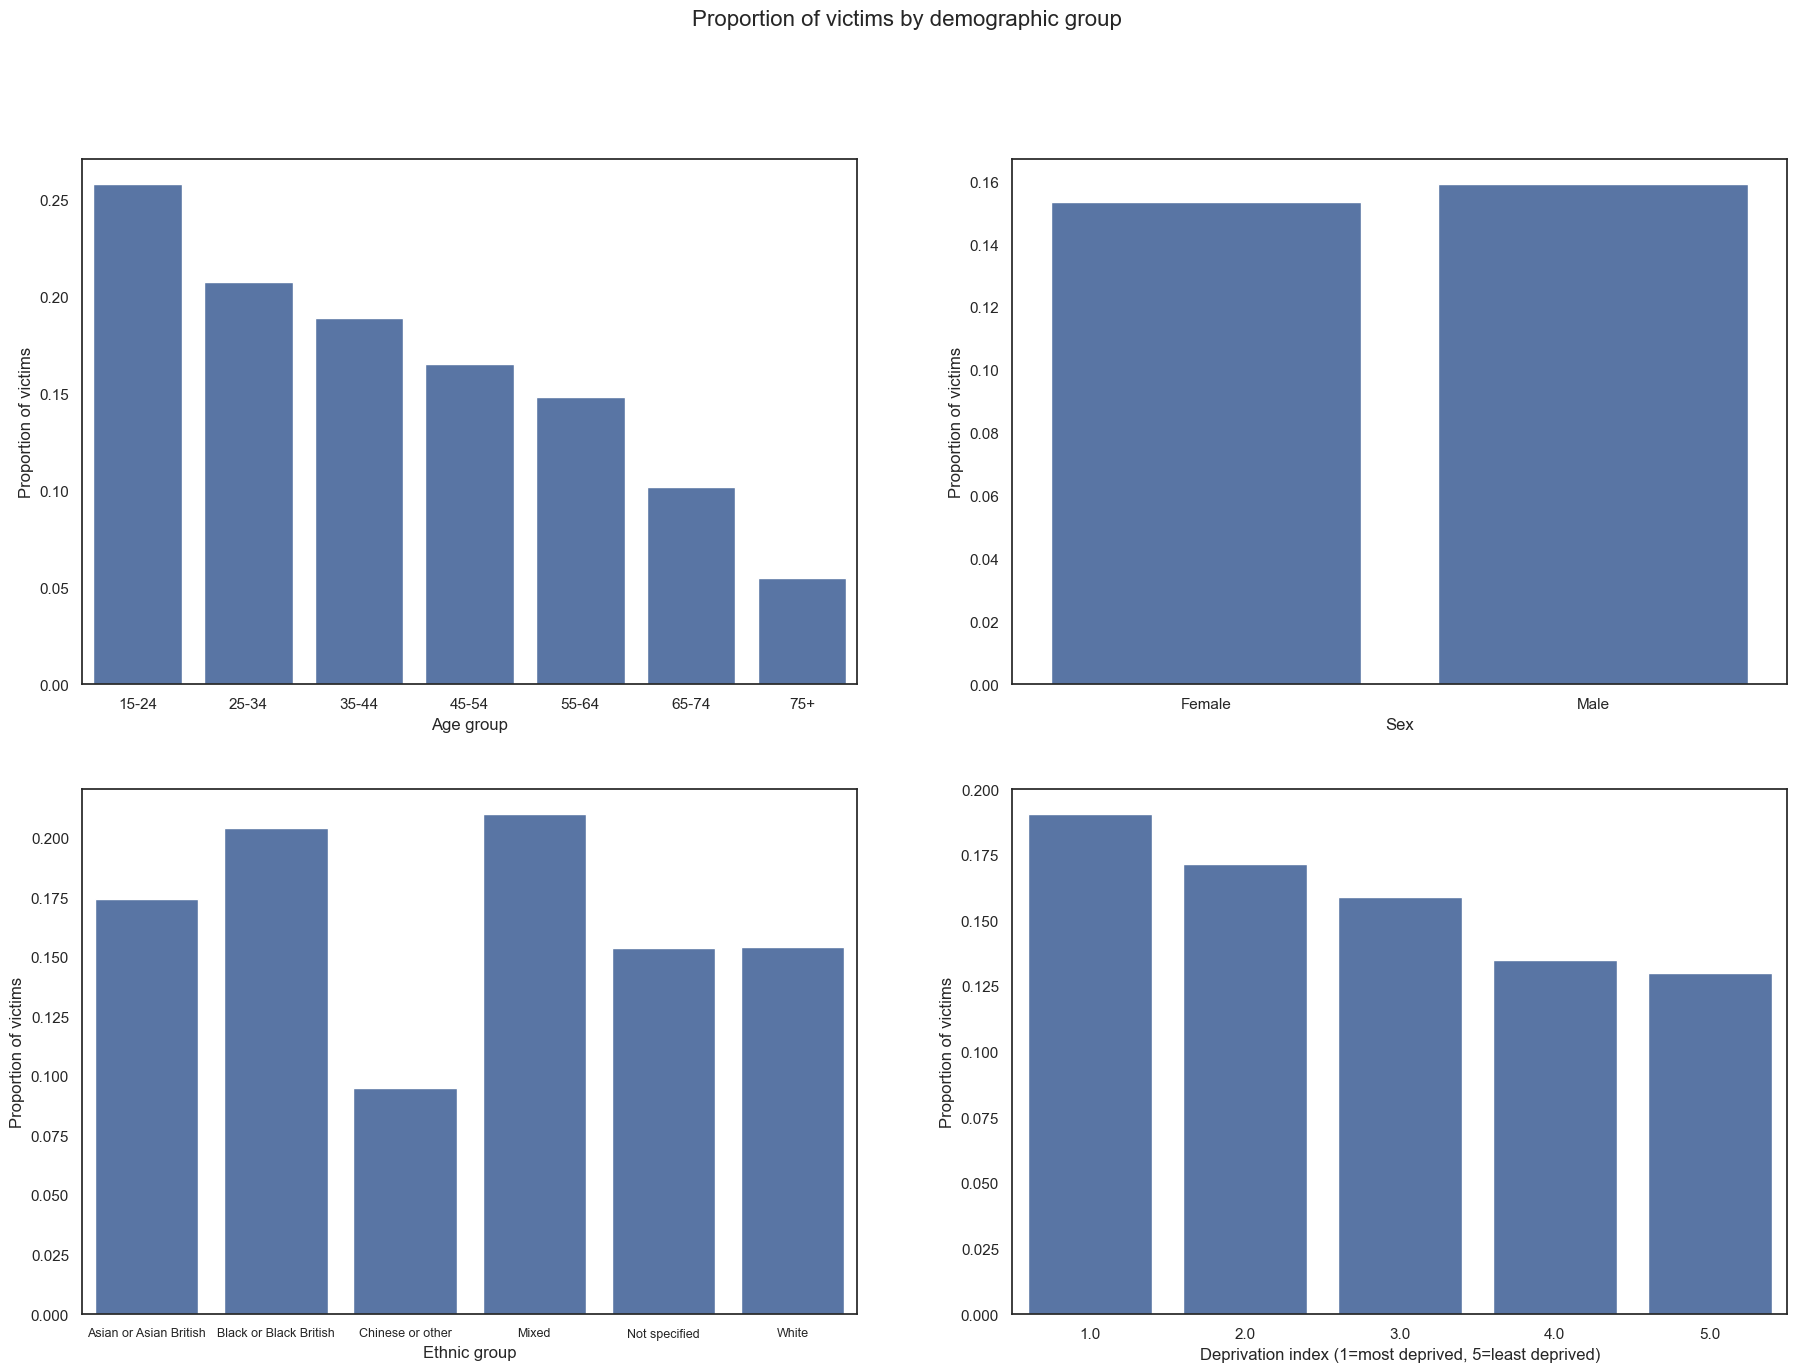

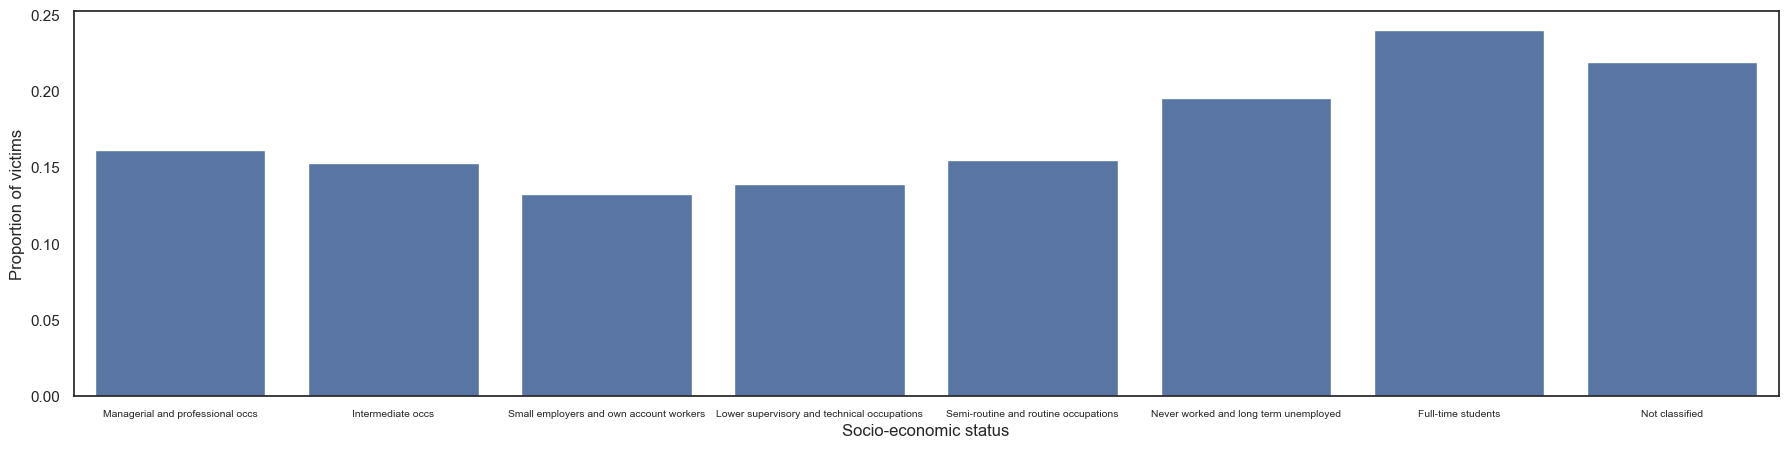

Black and Mixed ethnicities are 25.54 % more likely to be victims of crime than White ethnicities.


In [45]:

plt.figure(figsize=(22,15))
plt.suptitle("Proportion of victims by demographic group", fontsize=16)
plt.subplot(2,2,1)
agegroup_mean = crime.groupby('AgeGroup').Victim.mean()
agegroup_mean.index = agegroup_bins
sns.barplot(agegroup_mean)
plt.xlabel("Age group")
plt.ylabel("Proportion of victims")
agegroup_mean.apply(lambda x: str(round(x, 2)) +" %")

plt.subplot(2,2,2)
sns.barplot(crime.groupby('Sex').Victim.mean())
plt.ylabel("Proportion of victims")

plt.subplot(2,2,3)
sns.barplot(crime.groupby('EthnicGroup').Victim.mean())
plt.ylabel("Proportion of victims")
plt.xlabel("Ethnic group")
plt.xticks(fontsize=9)

plt.subplot(2,2,4)
sns.barplot(crime.groupby('DeprivationIndex').Victim.mean())
plt.ylabel("Proportion of victims")
plt.xlabel("Deprivation index (1=most deprived, 5=least deprived)")


plt.figure(figsize=(22,5))
ses_mean = crime.groupby('SES').Victim.mean()

ses_mean.index = ["Managerial and professional occs",
 "Intermediate occs",
 "Small employers and own account workers",
 "Lower supervisory and technical occupations",
 "Semi-routine and routine occupations",
 "Never worked and long term unemployed",
 "Full-time students",
 "Not classified"]

sns.barplot(ses_mean)
plt.ylabel("Proportion of victims")
plt.xlabel("Socio-economic status")
plt.xticks(fontsize=7.5)

plt.show()

black = crime.groupby('EthnicGroup').Victim.mean()['Black or Black British']
mixed = crime.groupby('EthnicGroup').Victim.mean()['Mixed']
white = crime.groupby('EthnicGroup').Victim.mean()['White']

print("Black and Mixed ethnicities are", round((1-white/((black + mixed)/2))*100,2), "% more likely to be victims of crime than White ethnicities.")



Other trends have also been observed:
- Students from medium-deprived neighbourhoods were victims more often than would be expected. (visible in the left chart below with students in pink)
- **Black and mixed ethnicities** from **older age groups** were more like ly to be victims than would be expected for their age. (visible in the right chart, black ethnicities in red, mixed in green)

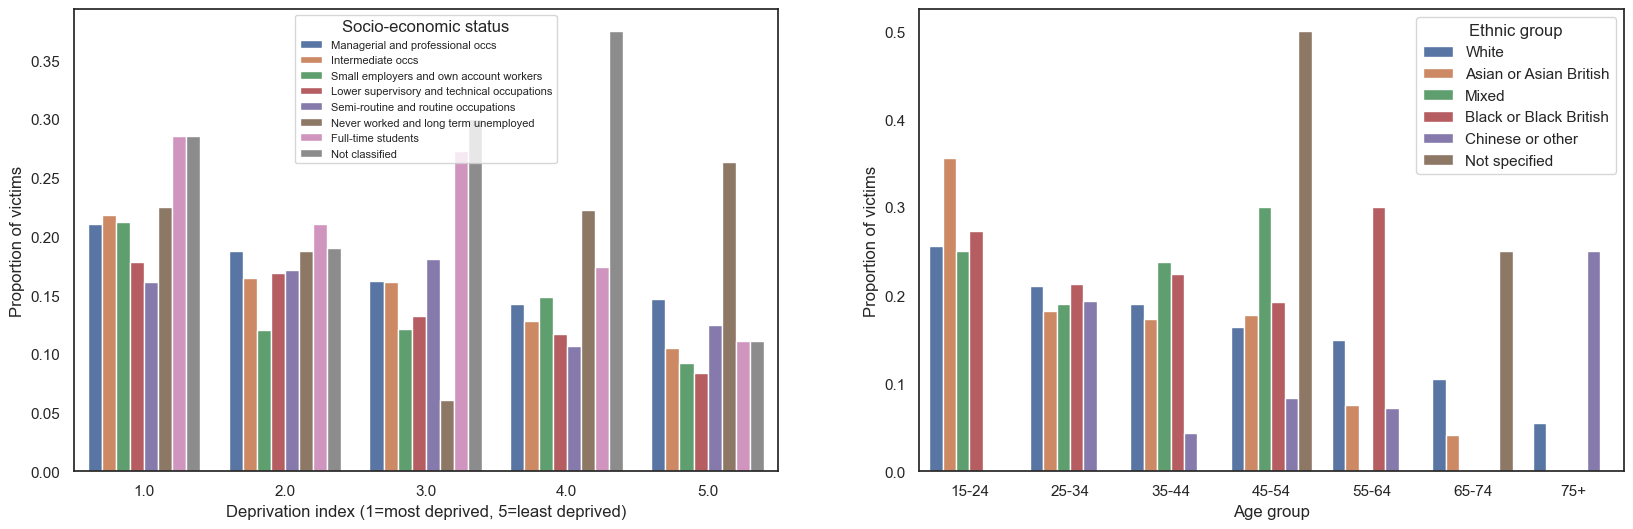

In [28]:
crime["SES_str"] = crime.SES.astype(str)

plt.figure(figsize=(20,6))
plt.subplot(1,2,1)

sns.barplot(crime.sort_values(by="SES_str"), x="DeprivationIndex", hue="SES_str", y="Victim", estimator="mean", errorbar=None)


plt.ylabel("Proportion of victims")
plt.xlabel("Deprivation index (1=most deprived, 5=least deprived)")
plt.legend(title="Socio-economic status", fontsize=8, loc='upper center',
             labels= [
                    "Managerial and professional occs",
                    "Intermediate occs",
                    "Small employers and own account workers",
                    "Lower supervisory and technical occupations",
                    "Semi-routine and routine occupations",
                    "Never worked and long term unemployed",
                    "Full-time students",
                    "Not classified"])

plt.subplot(1,2,2)
sns.barplot(crime, x='AgeGroup', y='Victim', hue='EthnicGroup', estimator='mean', errorbar=None)
plt.xticks(ticks=range(7), labels=agegroup_bins)

plt.ylabel("Proportion of victims")
plt.xlabel("Age group")
plt.legend(title="Ethnic group")

plt.show()

## 2. Confidence in policing

A part of the survey asked the respondend how confident they feel about the police force. Their responses varied widely across different demographics:
- People under 65 years tend to have negative confidence which increases with their age, whereas respondents aged 65 or older are much more confident.
- Men are much less confident than women, having a completely opposite opinion of the police force.
- White people have a neutral opition of the police, people of asian ethnicities tend to be confident and people with back or mixed ethnicities have a negative confidence index.
- Confidence in the police is very closely related to income (deprivation index) - people from lower income bacgrounds have a very low confidence in police.
- In terms of socioeconomic status, unemployed individuals have a very low confidence and students have the highest.

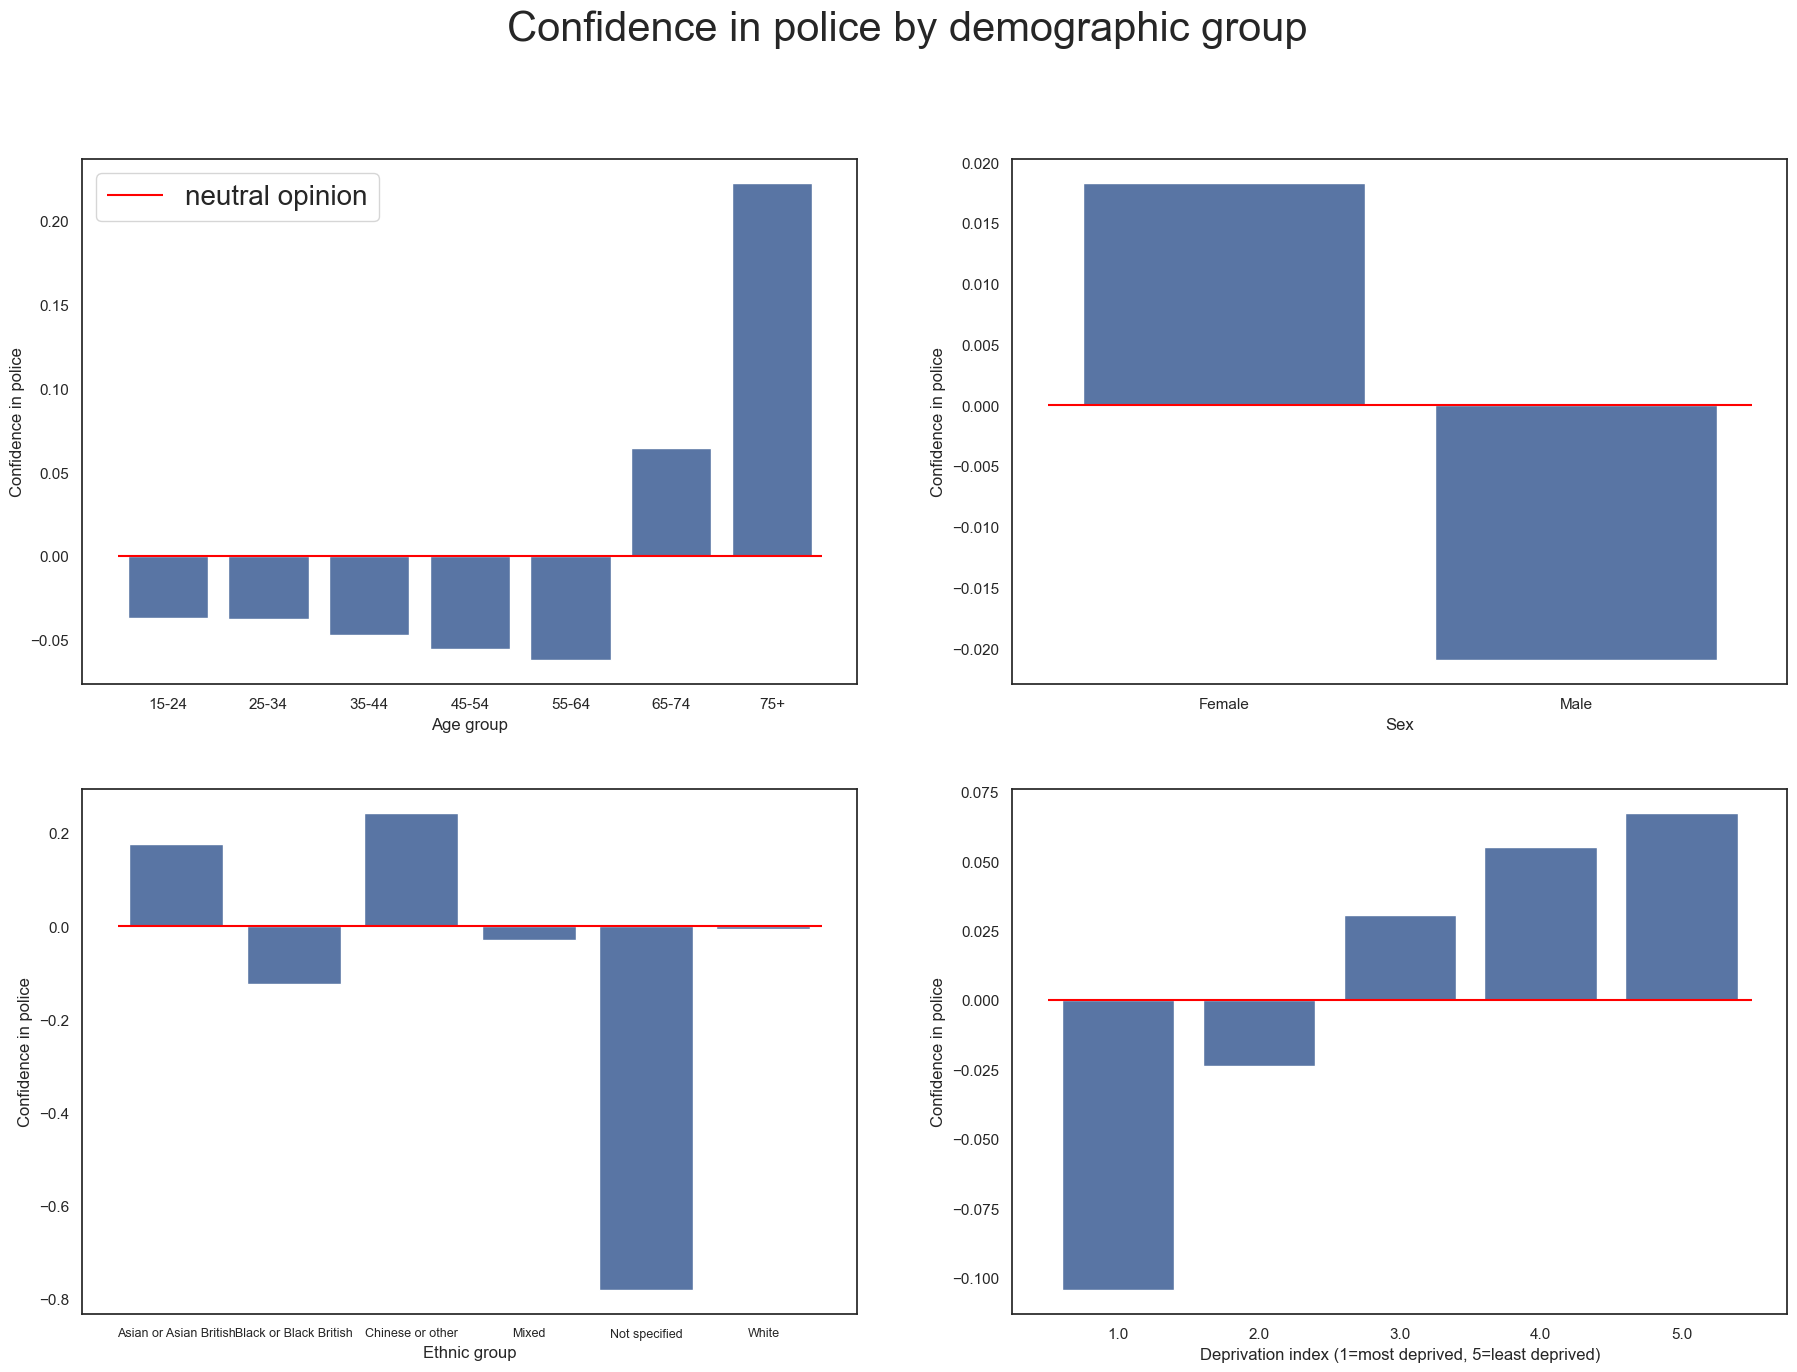

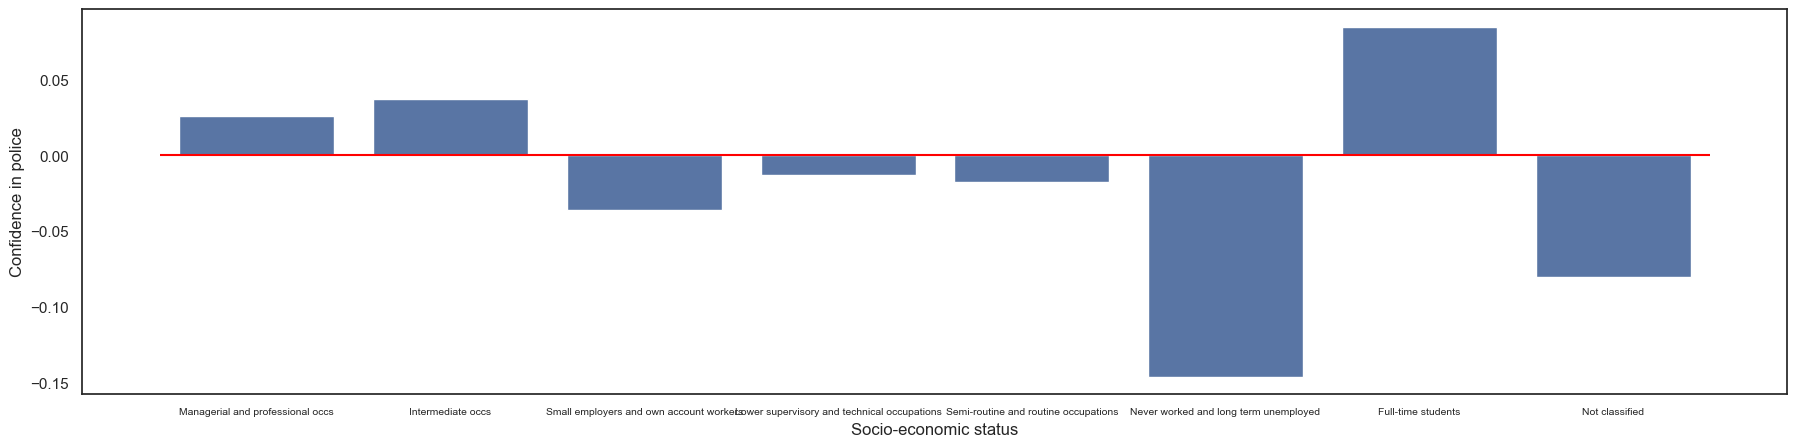

In [49]:
plt.figure(figsize=(22,15))
plt.suptitle("Confidence in police by demographic group", fontsize=30)
plt.subplot(2,2,1)
agegroup_mean = crime.groupby('AgeGroup').confpolice.mean()
agegroup_mean.index = agegroup_bins
sns.barplot(agegroup_mean)
plt.xlabel("Age group")
plt.ylabel("Confidence in police")
plt.hlines(0, xmin=-0.5, xmax=len(crime.groupby('AgeGroup').confpolice.mean())-0.5, colors='red', label='neutral opinion')
agegroup_mean.apply(lambda x: str(round(x, 2)) +" %")
plt.legend(fontsize=20)

plt.subplot(2,2,2)
sns.barplot(crime.groupby('Sex').confpolice.mean())
plt.hlines(0, xmin=-0.5, xmax=len(crime.groupby('Sex').confpolice.mean())-0.5, colors='red', label='neutral opinion')
plt.ylabel("Confidence in police")

plt.subplot(2,2,3)
sns.barplot(crime.groupby('EthnicGroup').confpolice.mean())
plt.hlines(0, xmin=-0.5, xmax=len(crime.groupby('EthnicGroup').confpolice.mean())-0.5, colors='red', label='neutral opinion')
plt.ylabel("Confidence in police")
plt.xlabel("Ethnic group")
plt.xticks(fontsize=9)

plt.subplot(2,2,4)
sns.barplot(crime.groupby('DeprivationIndex').confpolice.mean())
plt.hlines(0, xmin=-0.5, xmax=len(crime.groupby('DeprivationIndex').confpolice.mean())-0.5, colors='red', label='neutral opinion')
plt.ylabel("Confidence in police")
plt.xlabel("Deprivation index (1=most deprived, 5=least deprived)")


plt.figure(figsize=(22,5))
ses_mean = crime.groupby('SES').confpolice.mean()

ses_mean.index = ["Managerial and professional occs",
 "Intermediate occs",
 "Small employers and own account workers",
 "Lower supervisory and technical occupations",
 "Semi-routine and routine occupations",
 "Never worked and long term unemployed",
 "Full-time students",
 "Not classified"]

sns.barplot(ses_mean)
plt.hlines(0, xmin=-0.5, xmax=len(crime.groupby('SES').confpolice.mean())-0.5, colors='red', label='neutral opinion')
plt.ylabel("Confidence in police")
plt.xlabel("Socio-economic status")
plt.xticks(fontsize=7.5)

plt.show()




#### Relation of confidence in police and reported antisocial behavior in the neighbourhood

Respondents were also asked to evaluate the level of antisocial behavior in their neighborhood.
This parameter seems to mildly influence the reported confidence in police, though it is not very significant.

correlation between confidence in police and perception of antisocial behavior: 0.228


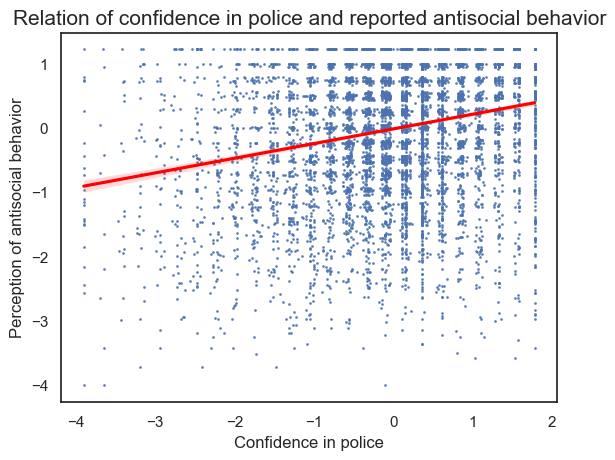

In [73]:
sns.regplot(x=crime.confpolice, y=crime.antisoc, scatter_kws={'s':1}, line_kws={'color':'red'})
plt.ylabel("Perception of antisocial behavior")
plt.xlabel("Confidence in police")
plt.title("Relation of confidence in police and reported antisocial behavior", fontsize=15)

print("correlation between confidence in police and perception of antisocial behavior:", round(crime.confpolice.corr(crime.antisoc), 3))

The effect of antisocial behavior on perception of police seems to be slightly more apparent in higher deprived areas and in younger people.

C:\Users\vrtul\AppData\Local\Temp\ipykernel_26900\2509138640.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  agegroup_mean = crime.groupby('AgeGroup').apply(lambda col: col.confpolice.corr(col.antisoc))
C:\Users\vrtul\AppData\Local\Temp\ipykernel_26900\2509138640.py:12: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  sns.barplot(crime.groupby('Sex').apply(lambda col: col.confpolice.corr(col.antisoc)))
C:\

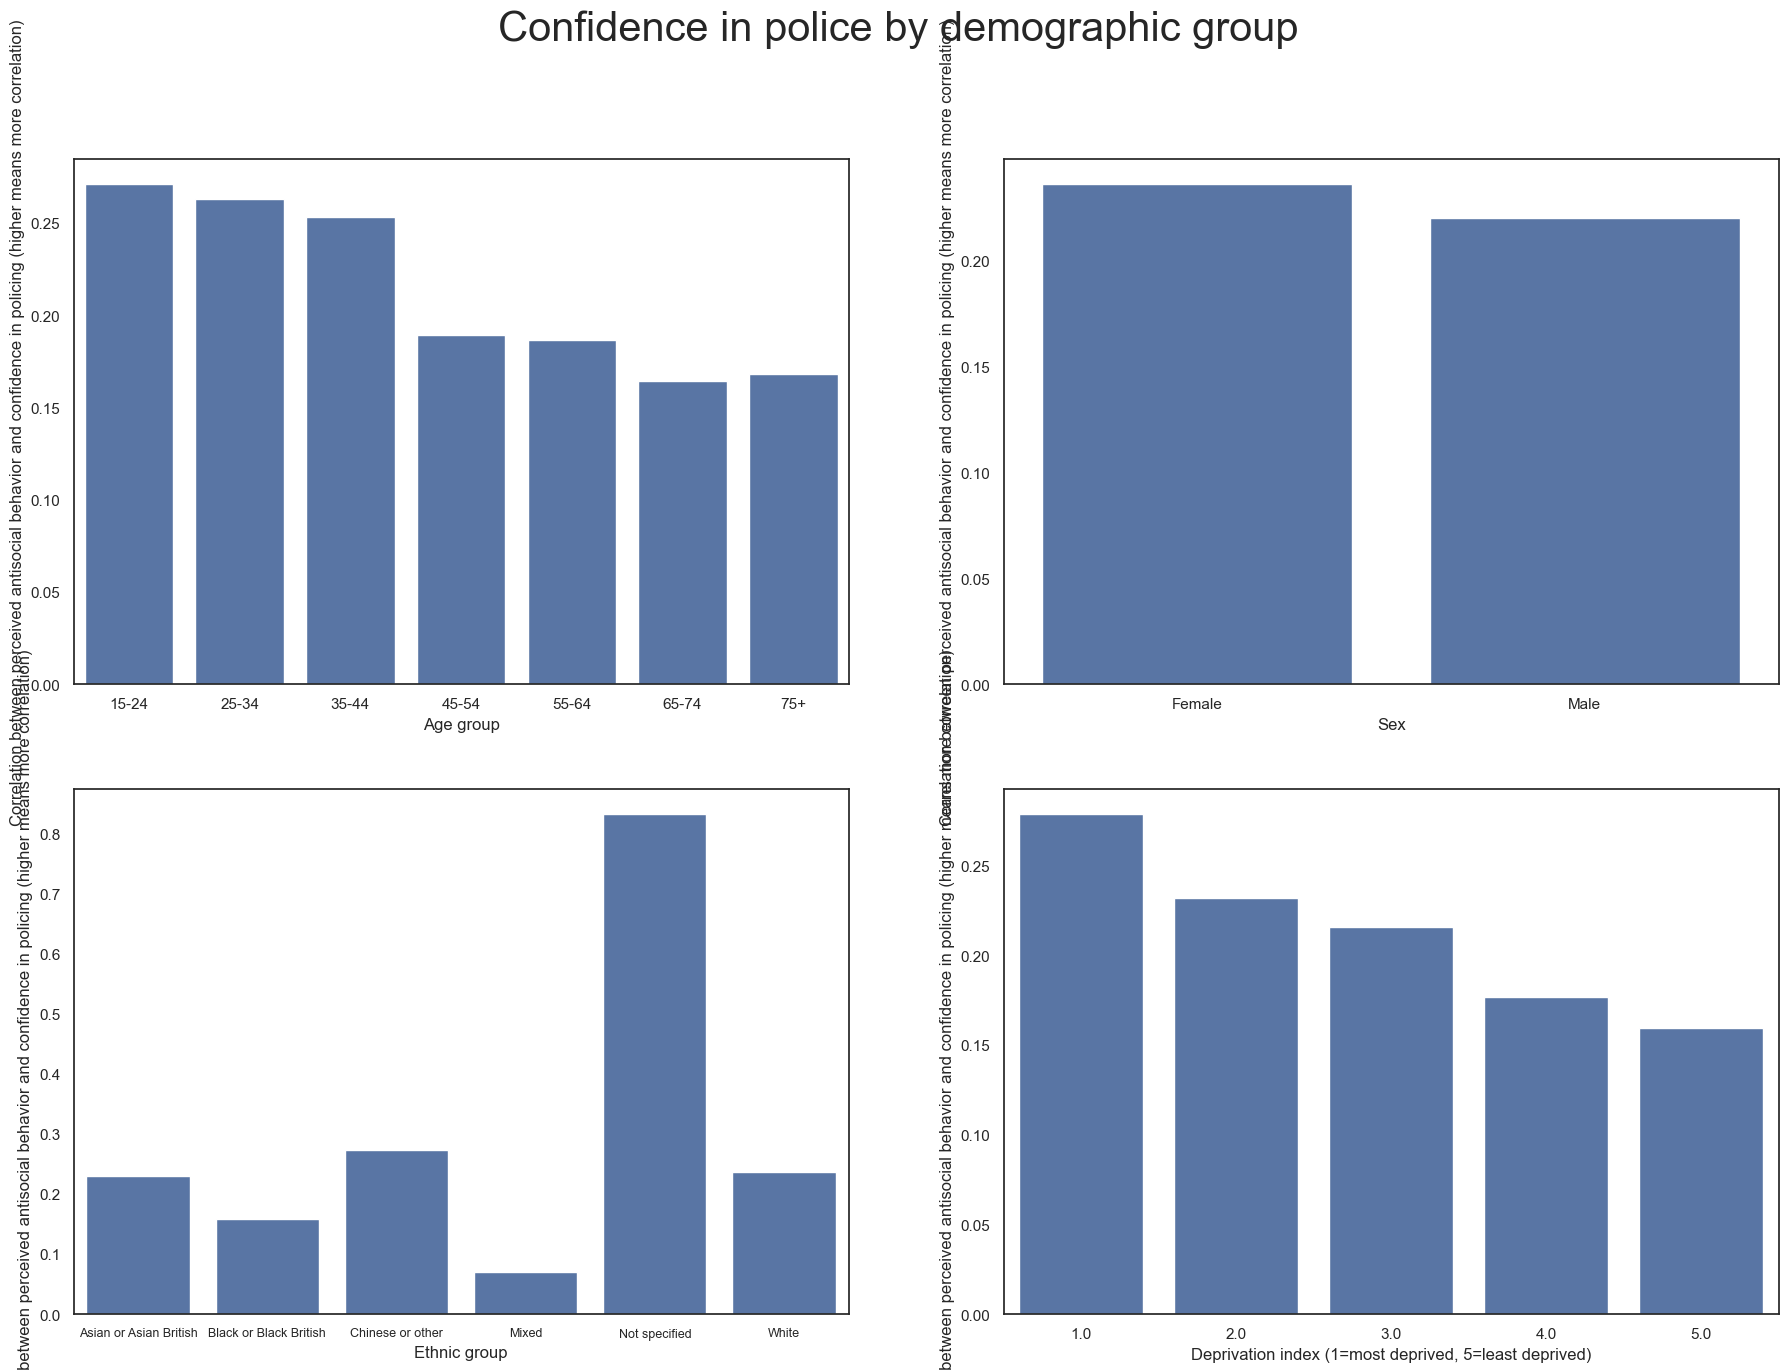

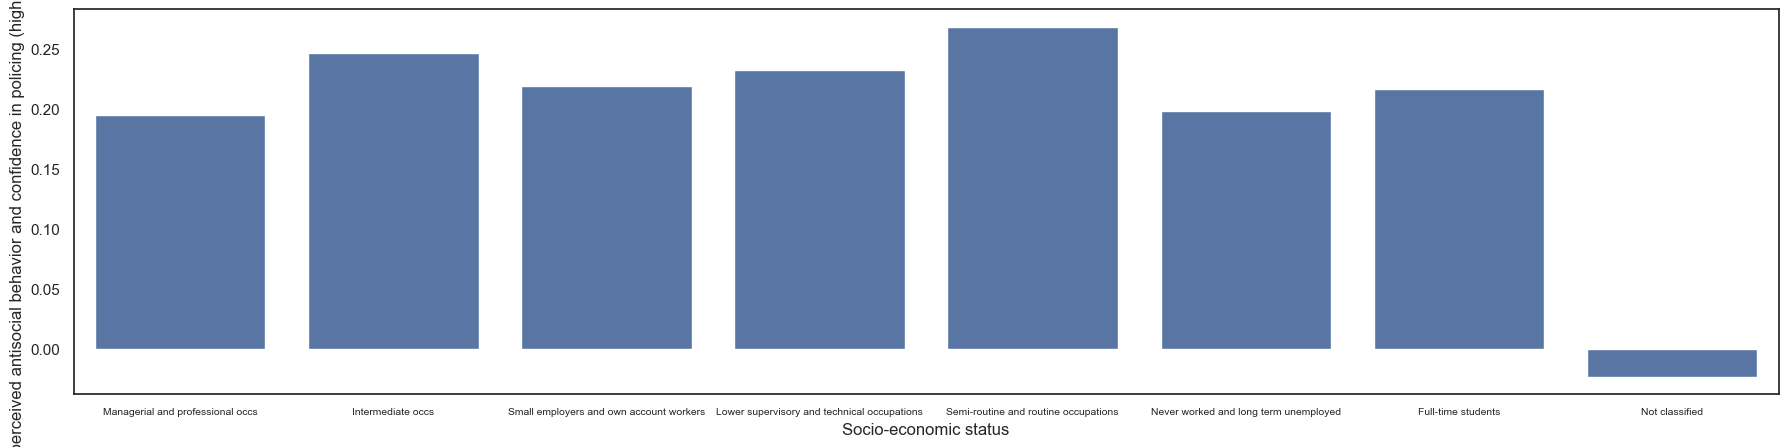

In [79]:
plt.figure(figsize=(22,15))
plt.suptitle("Confidence in police by demographic group", fontsize=30)
plt.subplot(2,2,1)
agegroup_mean = crime.groupby('AgeGroup').apply(lambda col: col.confpolice.corr(col.antisoc))
agegroup_mean.index = agegroup_bins
sns.barplot(agegroup_mean)
plt.xlabel("Age group")
plt.ylabel("Correlation between perceived antisocial behavior and confidence in policing (higher means more correlation)")
agegroup_mean.apply(lambda x: str(round(x, 2)) +" %")

plt.subplot(2,2,2)
sns.barplot(crime.groupby('Sex').apply(lambda col: col.confpolice.corr(col.antisoc)))
plt.ylabel("Correlation between perceived antisocial behavior and confidence in policing (higher means more correlation)")

plt.subplot(2,2,3)
sns.barplot(crime.groupby('EthnicGroup').apply(lambda col: col.confpolice.corr(col.antisoc)))
plt.ylabel("Correlation between perceived antisocial behavior and confidence in policing (higher means more correlation)")
plt.xlabel("Ethnic group")
plt.xticks(fontsize=9)

plt.subplot(2,2,4)
sns.barplot(crime.groupby('DeprivationIndex').apply(lambda col: col.confpolice.corr(col.antisoc)))
plt.ylabel("Correlation between perceived antisocial behavior and confidence in policing (higher means more correlation)")
plt.xlabel("Deprivation index (1=most deprived, 5=least deprived)")


plt.figure(figsize=(22,5))
ses_mean = crime.groupby('SES').apply(lambda col: col.confpolice.corr(col.antisoc))

ses_mean.index = ["Managerial and professional occs",
 "Intermediate occs",
 "Small employers and own account workers",
 "Lower supervisory and technical occupations",
 "Semi-routine and routine occupations",
 "Never worked and long term unemployed",
 "Full-time students",
 "Not classified"]

sns.barplot(ses_mean)
plt.ylabel("Correlation between perceived antisocial behavior and confidence in policing (higher means more correlation)")
plt.xlabel("Socio-economic status")
plt.xticks(fontsize=7.5)

plt.show()

## Conclusions and recommendations

Measures preventing crime should be increased in a way that targets demographic groups according to their identified vulnerability, such as increasing protection in more deprived areas or for neighborhoods where black and mixed ethnicities are more present.

As the confidence varied widely across different demographics, further analysis should go into why certain groups, such as younger people or males, are feeling this way, and how can this be improved.

Also, decreasing the perceived antisocial behavior of the population could lead to an increase in confidence. Thsi could be achieved 